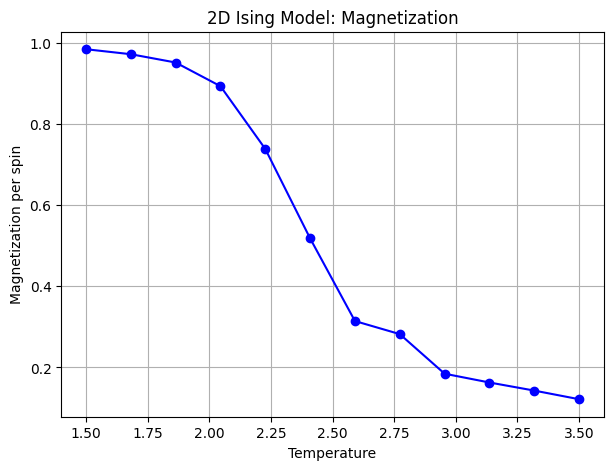

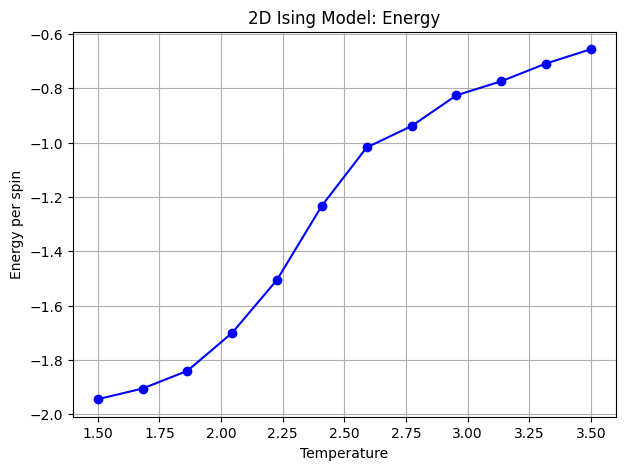

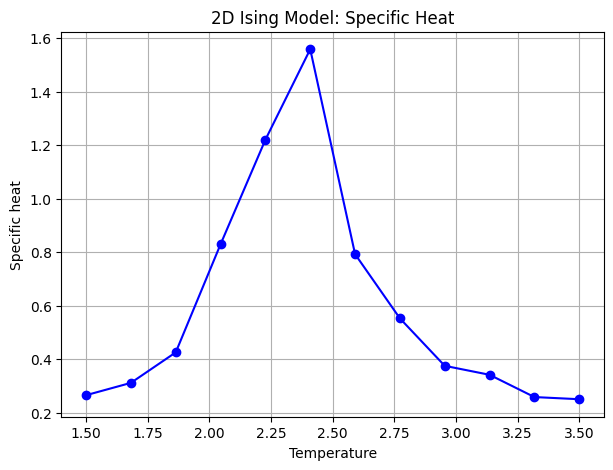

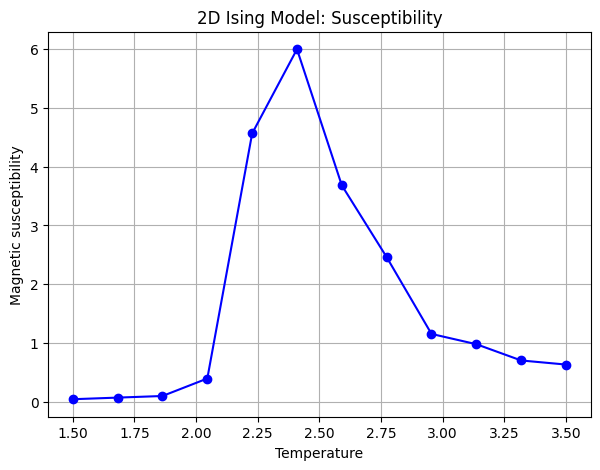

In [2]:
import numpy as np
import matplotlib.pyplot as plt

L = 15
J = 1.0
kB = 1.0

temperatures = np.linspace(1.5, 3.5, 12)

equilibration_steps = 200
measurement_steps = 500


def initialize_lattice(L):
    return np.random.choice([-1, 1], size=(L, L))


def energy(spins, J):
    E = 0

    E -= J * np.sum(
        spins * np.roll(spins, 1, axis=0)
    )

    E -= J * np.sum(
        spins * np.roll(spins, 1, axis=1)
    )

    return E


def magnetization(spins):
    return np.sum(spins)


def metropolis_step(spins, T, J):

    L = spins.shape[0]

    for _ in range(L * L):

        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

        spin = spins[i, j]

        neighbours = (
            spins[(i + 1) % L, j]
            + spins[(i - 1) % L, j]
            + spins[i, (j + 1) % L]
            + spins[i, (j - 1) % L]
        )

        dE = 2 * J * spin * neighbours

        if dE <= 0:
            spins[i, j] *= -1

        elif np.random.random() < np.exp(-dE / (kB * T)):
            spins[i, j] *= -1


energies = []
magnetizations = []
specific_heats = []
susceptibilities = []


for T in temperatures:

    spins = initialize_lattice(L)

    for step in range(equilibration_steps):
        metropolis_step(spins, T, J)

    E_values = []
    M_values = []

    for step in range(measurement_steps):

        metropolis_step(spins, T, J)

        E_values.append(energy(spins, J))
        M_values.append(abs(magnetization(spins)))

    E_values = np.array(E_values)
    M_values = np.array(M_values)

    energies.append(
        np.mean(E_values) / (L * L)
    )

    magnetizations.append(
        np.mean(M_values) / (L * L)
    )

    specific_heats.append(
        np.var(E_values) /
        (kB * T**2 * L * L)
    )

    susceptibilities.append(
        np.var(M_values) /
        (kB * T * L * L)
    )


energies = np.array(energies)
magnetizations = np.array(magnetizations)
specific_heats = np.array(specific_heats)
susceptibilities = np.array(susceptibilities)


plt.figure(figsize=(7, 5))
plt.plot(temperatures, magnetizations, "o-", color='blue')
plt.xlabel("Temperature")
plt.ylabel("Magnetization per spin")
plt.title("2D Ising Model: Magnetization")
plt.grid()
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(temperatures, energies, "o-", color='blue')
plt.xlabel("Temperature")
plt.ylabel("Energy per spin")
plt.title("2D Ising Model: Energy")
plt.grid()
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(temperatures, specific_heats, "o-", color='blue')
plt.xlabel("Temperature")
plt.ylabel("Specific heat")
plt.title("2D Ising Model: Specific Heat")
plt.grid()
plt.show()


plt.figure(figsize=(7, 5))
plt.plot(temperatures, susceptibilities, "o-", color='blue')
plt.xlabel("Temperature")
plt.ylabel("Magnetic susceptibility")
plt.title("2D Ising Model: Susceptibility")
plt.grid()
plt.show()